In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# define the folder 
path = r"C:\Users\kumar\Desktop\Lung_cancer_detection\lung_colon_image_set\lung_image_sets"

In [3]:
# create the training Set 
train_data = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 15000 files belonging to 3 classes.
Using 12000 files for training.


In [5]:
# create the testing/validation set
val_data = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 15000 files belonging to 3 classes.
Using 3000 files for validation.


In [6]:
from tensorflow.keras import layers, models

In [7]:
# define the model
model = models.Sequential([
    # 1. new input layer: tells keras the image size
    layers.Input(shape=(128, 128, 3)),
    
    # 2. rescaling: now we don't need input_shape here
    layers.Rescaling(1./255),
    
    # 3. first convolution & pooling
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 4. second convolution & pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 5. flatten & output
    layers.Flatten(),
    layers.Dense(3) # Still 3 for lung_aca, lung_n, lung_scc
])

In [8]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# This shows a table summarizing your model's layers
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │         172,803 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 192,195 (750.76 KB)

 Trainable params: 192,195 (750.76 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 106s 275ms/step - accuracy: 0.8005 - loss: 0.4423 - val_accuracy: 0.8803 - val_loss: 0.2729
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 93s 248ms/step - accuracy: 0.8912 - loss: 0.2676 - val_accuracy: 0.8770 - val_loss: 0.3544
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 89s 238ms/step - accuracy: 0.9059 - loss: 0.2371 - val_accuracy: 0.8650 - val_loss: 0.3935
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 98s 260ms/step - accuracy: 0.9194 - loss: 0.2037 - val_accuracy: 0.9157 - val_loss: 0.2219
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 96s 257ms/step - accuracy: 0.9341 - loss: 0.1655 - val_accuracy: 0.9153 - val_loss: 0.2509
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 89s 237ms/step - accuracy: 0.9441 - loss: 0.1441 - val_accuracy: 0.8810 - val_loss: 0.3524
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 266ms/step - accuracy: 0.9509 - loss: 0.1270 - val_accuracy: 0.9107 - val_loss: 0.2420
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 129s 231ms/step - accuracy: 0.9577 - loss

In [13]:
# 'evaluate' runs the model on your Testing Set (val_ds)
test_loss, test_acc = model.evaluate(val_data)

print(f"Final Testing Accuracy: {test_acc * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9080 - loss: 0.3340
Final Testing Accuracy: 90.80%


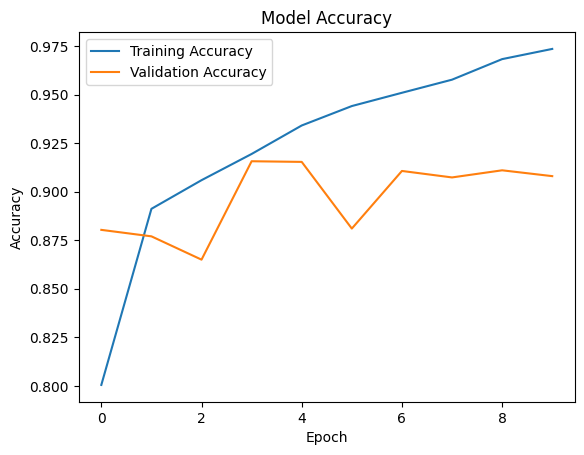

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [16]:
# This pulls the folder names directly from your training data
class_names = train_data.class_names
print("Class names are:", class_names)

Class names are: ['lung_aca', 'lung_n', 'lung_scc']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


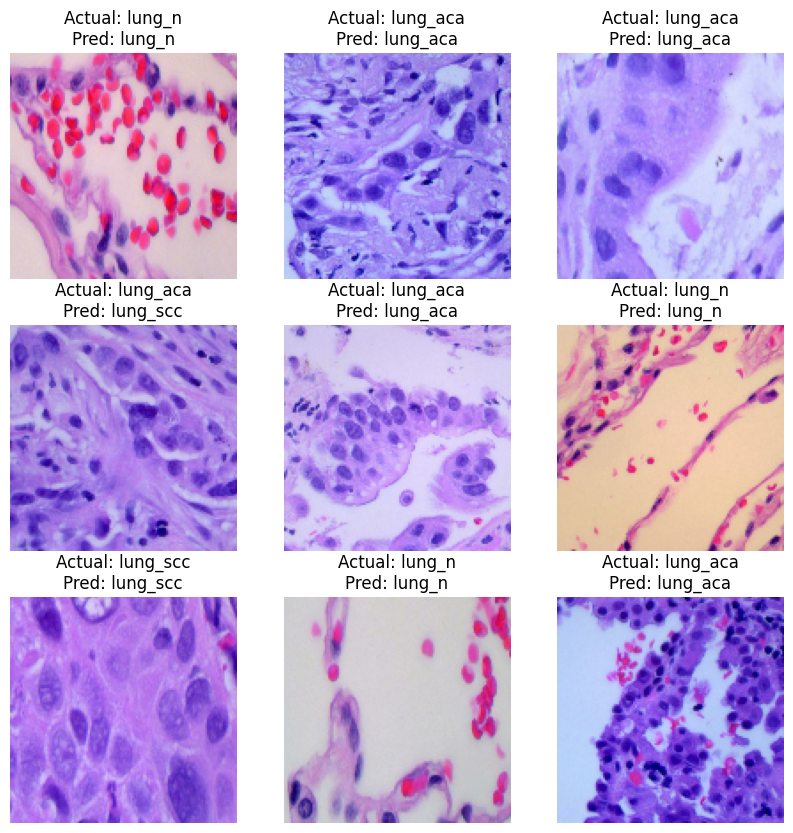

In [17]:
# Take one batch (32 images) from the testing set
plt.figure(figsize=(5, 4))
for images, labels in val_data.take(1):
    # Let the model make a guess
    predictions = model.predict(images)
    
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Get the class with the highest probability
        predicted_label = class_names[tf.argmax(predictions[i])]
        actual_label = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_label}\nPred: {predicted_label}")
        plt.axis("off")